---
## Step 1 — Install and Import Libraries

In [1]:
# Install XGBoost if not already installed
! pip install xgboost

In [2]:
# Import packages
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from pathlib import Path
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("All libraries imported successfully!")


All libraries imported successfully!


---
## Step 2 — Set the Data Folder

In [3]:
# Detect project root automatically.
# This makes the notebook more portable across different machines.
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

# If running from /notebooks, go one level up. Otherwise use current folder.
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "outputs"
FALLBACK_DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Primary data folder:", DATA_DIR)
print("Fallback data folder:", FALLBACK_DATA_DIR)


Project root: /home/ana/cosas_eukene/accounts/github/time_series_analysis_ona
Primary data folder: /home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/outputs
Fallback data folder: /home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/data


---
## Step 3 — Load the Dataset

In [4]:
# Load the feature-engineered dataset.
# The notebook first looks in /outputs, then falls back to /data.

data_path = DATA_DIR / "timeseries_with_features.csv"

if not data_path.exists():
    data_path = FALLBACK_DATA_DIR / "timeseries_with_features.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "Could not find timeseries_with_features.csv in either outputs/ or data/. "
        "Please make sure the feature-engineered dataset has been exported."
    )

df = pd.read_csv(data_path)

# Convert date column to datetime and set as index
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

# Drop rows with NaN values caused by lag/rolling feature creation
df = df.dropna()

print("Dataset loaded successfully!")
print("Path:", data_path)
print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
display(df.head())


Dataset loaded successfully!
Path: /home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/outputs/timeseries_with_features.csv
Shape: (424, 30)
Date range: 2013-02-01 to 2014-03-31


,unit_sales,day_of_week,day_number,month,year,is_weekend,rolling_7d,zscore,is_outlier,dcoilwtico,...,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_lag_1,oil_lag_7,oil_rolling_7d_mean
date,,,,,,,,,,,,,,,,,,,,,
2013-02-01,401.0,Friday,4,2,2013,0,456.285714,-0.444388,False,97.46,...,389.0,60.0,582.0,454.571429,497.071429,520.833333,154.059358,97.65,95.15,96.378571
2013-02-02,775.0,Saturday,5,2,2013,1,467.428571,1.714749,False,97.46,...,697.0,667.0,310.0,456.285714,521.428571,514.800000,153.272866,97.46,95.15,96.708571
2013-02-03,855.0,Sunday,6,2,2013,1,501.571429,2.176596,False,97.46,...,616.0,1090.0,338.0,467.428571,529.142857,530.300000,174.986530,97.46,95.15,97.038571
2013-02-04,411.0,Monday,0,2,2013,0,514.857143,-0.386657,False,96.21,...,318.0,760.0,654.0,501.571429,512.357143,547.533333,224.981375,97.46,95.95,97.368571
2013-02-05,272.0,Tuesday,1,2,2013,0,497.571429,-1.189117,False,96.68,...,393.0,461.0,979.0,514.857143,487.428571,539.433333,214.852219,96.21,97.62,97.405714


---
## Step 4 — Explore the Data

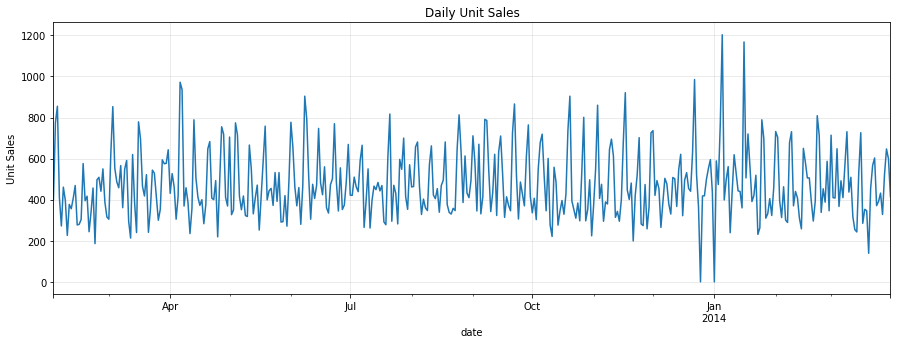

In [5]:
# Plot unit_sales over time
df['unit_sales'].plot(figsize=(15, 5), title='Daily Unit Sales')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.show()

---
## Step 5 — Train / Test Split

We split the data by time — everything **before** January 1, 2014 is used for training,  
and everything **from** January 1, 2014 onwards is used for testing.

We never split time series data randomly — the model must always train on the past and predict the future.

In [6]:
split_date = '01-Jan-2014'

df_train = df.loc[df.index < split_date].copy()   # Train on past data
df_test  = df.loc[df.index >= split_date].copy()  # Test on future data

print("Training rows:", len(df_train))
print("  From:", df_train.index.min().date(), "to", df_train.index.max().date())
print()
print("Test rows:", len(df_test))
print("  From:", df_test.index.min().date(), "to", df_test.index.max().date())

Training rows: 334
  From: 2013-02-01 to 2013-12-31

Test rows: 90
  From: 2014-01-01 to 2014-03-31


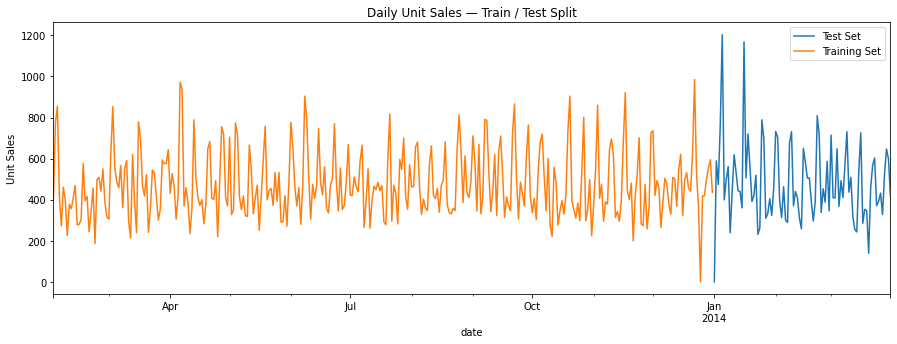

In [7]:
# Visualise the train / test split

test_renamed  = df_test[['unit_sales']].rename(columns={'unit_sales': 'Test Set'})
train_renamed = df_train[['unit_sales']].rename(columns={'unit_sales': 'Training Set'})

combined_data = test_renamed.join(train_renamed, how='outer')

combined_data.plot(
    figsize=(15, 5),
    title='Daily Unit Sales — Train / Test Split'
)
plt.ylabel('Unit Sales')
plt.show()

---
## Step 6 — Define Features and Target

Because our CSV already contains all the engineered features  
(lag values, rolling averages, calendar flags, oil price, holidays),  
we do not need a `create_features()` function.  
We simply select which columns to use as inputs to the model.

In [10]:
# ============================================================
# Feature Selection and Validation
# ============================================================

# Define input features used by the XGBoost model
features = [

    # Calendar features
    "year",
    "month",
    "day_number",
    "day_of_week",
    "quarter",
    "week_of_year",
    "is_weekend",
    "is_month_start",
    "is_month_end",

    # Lag features
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",

    # Rolling window statistics
    "rolling_7d_mean",
    "rolling_14d_mean",
    "rolling_30d_mean",
    "rolling_7d_std",

    # Oil price features
    "dcoilwtico",
    "oil_lag_1",
    "oil_rolling_7d_mean",

    # Holiday indicators
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
]

# Target variable
target = "unit_sales"

# ============================================================
# Validate required columns
# ============================================================

required_columns = features + [target]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Feature validation passed.")
print(f"Number of features: {len(features)}")

# ============================================================
# Train/Test Split
# ============================================================

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Feature validation passed.
Number of features: 23
Training samples: 334
Test samples: 90


---
## Step 7 — Build and Train the XGBoost Model

**Key parameters:**
- `n_estimators` — the number of decision trees to build
- `early_stopping_rounds` — if the model stops improving after 50 trees, training stops automatically

In [13]:
# ============================================================
# Prepare Features for XGBoost
# ============================================================

# Convert day_of_week from text to numeric
day_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6,
}

df["day_of_week_num"] = df["day_of_week"].map(day_mapping)

# Chronological train/test split
df_train = df[df.index < "2014-01-01"].copy()
df_test = df[df.index >= "2014-01-01"].copy()

features = [
    "year",
    "month",
    "day_number",
    "day_of_week_num",
    "is_weekend",

    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",

    "rolling_7d_mean",
    "rolling_14d_mean",
    "rolling_30d_mean",
    "rolling_7d_std",

    "dcoilwtico",
    "oil_lag_1",
    "oil_rolling_7d_mean",
]

target = "unit_sales"

# Validate columns
required_columns = features + [target]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]

print("Feature validation passed.")
print(f"Number of features: {len(features)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Feature validation passed.
Number of features: 16
Training samples: 334
Test samples: 90


In [14]:
# ============================================================
# Train XGBoost Model
# ============================================================

reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric="rmse"
)

reg.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("Model training complete!")
print("Best iteration:", reg.best_iteration)

Model training complete!
Best iteration: 65


---
## Step 8 — Feature Importance

Feature importance tells us **which features the model relied on most** when making predictions.

It is calculated by how often each feature is used to split data in the decision trees  
and how much each feature improves predictions when used.

<Figure size 864x576 with 0 Axes>

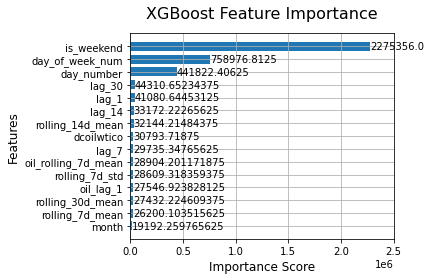

In [17]:
# ============================================================
# Feature Importance
# ============================================================

from xgboost import plot_importance

plt.figure(figsize=(12, 8))

plot_importance(
    reg,
    importance_type="gain",
    max_num_features=15,
    height=0.7
)

plt.title(
    "XGBoost Feature Importance",
    fontsize=16,
    pad=15
)

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

---
## Step 9 — Forecast on the Test Set

In [18]:
# Generate predictions and combine all data for analysis
df_test['xgb_prediction'] = reg.predict(X_test)   # Add predictions column
df_all = pd.concat([df_test, df_train])           # Combine test and training sets
df_all = df_all.sort_index()                      # Sort into chronological order

print("Predictions added.")
print("Combined dataset shape:", df_all.shape)

Predictions added.
Combined dataset shape: (422, 25)


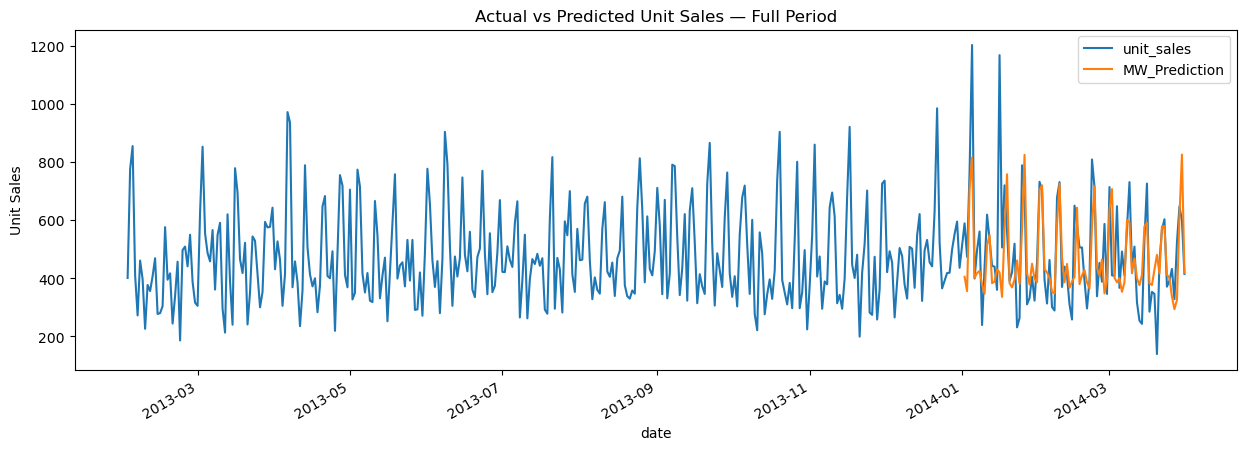

In [19]:
# Compare actual unit sales with model predictions — full period
df_all[['unit_sales', 'xgb_prediction']].plot(figsize=(15, 5))
plt.title('Actual vs Predicted Unit Sales — Full Period')
plt.ylabel('Unit Sales')
plt.show()

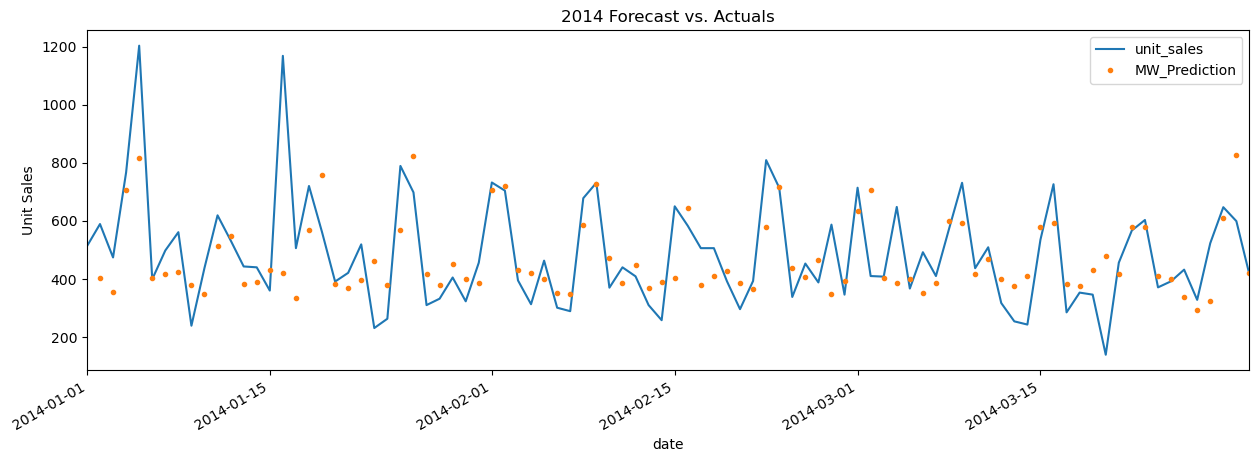

In [20]:
# Zoom into the test period only

fig, ax = plt.subplots(figsize=(15, 5))

df_all[['unit_sales', 'xgb_prediction']].plot(ax=ax, style=['-', '.'])
ax.set_xbound(lower='01-01-2014', upper='03-31-2014')  # Focus on test period
plt.title('2014 Forecast vs. Actuals')
plt.ylabel('Unit Sales')
plt.show()

---
## Step 10 — Worst and Best Predicted Days

We calculate how far off the model was each day and identify  
the days where it performed best and worst.

In [21]:
# Raw error — difference between actual and predicted
# Positive = model under-predicted, Negative = model over-predicted
df_test['error'] = df_test['unit_sales'] - df_test['xgb_prediction']

# Absolute error — always positive, measures size of error regardless of direction
df_test['abs_error'] = df_test['error'].apply(np.abs)

print("Error columns added.")
print()
print("Error summary:")
print(df_test[['error', 'abs_error']].describe().round(2))

Error columns added.

Error summary:
        error  abs_error
count   89.00      89.00
mean    17.30     102.65
std    146.48     105.36
min   -341.41       2.08
25%    -59.99      39.42
50%      5.29      76.81
75%     91.39     130.24
max    748.19     748.19


---

## Step 11 — Model Evaluation

We evaluate the model on the unseen test period using several metrics.

- **MAE**: average absolute error in units sold.
- **RMSE**: penalizes larger errors more strongly.
- **MAPE**: average percentage error.
- **Bias**: average signed error. Positive bias means the model tends to under-predict; negative bias means it tends to over-predict.


In [ ]:
# Evaluation metrics

y_pred = df_test["xgb_prediction"].values
y_true = y_test.values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
bias = np.mean(y_true - y_pred)
r2 = r2_score(y_true, y_pred)

metrics = pd.DataFrame({
    "model": ["XGBoost"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "Bias": [bias],
    "R2": [r2]
})

display(metrics.round(3))


### Interpretation Guide

Use this table to compare XGBoost with ARIMA, Holt-Winters, Prophet, Neural Networks, and the final MLflow champion model.

A strong model should have:

- low MAE,
- low RMSE,
- reasonable MAPE,
- and Bias close to zero.


---

## Step 12 — Residual Analysis

Residuals help us understand where the model is still making mistakes.

If residuals show a visible pattern over time, the model may still be missing important temporal signals.


In [ ]:
# Residual analysis

df_test["residual"] = df_test["unit_sales"] - df_test["xgb_prediction"]

plt.figure(figsize=(15, 5))
plt.plot(df_test.index, df_test["residual"])
plt.axhline(0, linestyle="--")
plt.title("XGBoost Residuals Over Time")
plt.ylabel("Actual - Predicted")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_test["residual"], bins=30)
plt.title("Distribution of XGBoost Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


---

## Step 13 — Save Model and Outputs

The trained model and its metadata are saved so they can be reused later in the MLflow and Streamlit notebooks.


In [ ]:
# Save model, feature list, metrics, and predictions

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

MODELS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

# Save trained model
with open(MODELS_DIR / "xgboost_model.pkl", "wb") as f:
    pickle.dump(reg, f)

# Save feature columns
with open(MODELS_DIR / "xgboost_feature_columns.json", "w") as f:
    json.dump(features, f, indent=4)

# Save metrics
metrics.to_csv(MODELS_DIR / "xgboost_metrics.csv", index=False)

# Save predictions
forecast_output = df_test[["unit_sales", "xgb_prediction", "error", "abs_error", "residual"]].copy()
forecast_output.to_csv(OUTPUTS_DIR / "xgboost_forecast_output.csv")

print("Saved files:")
print("-", MODELS_DIR / "xgboost_model.pkl")
print("-", MODELS_DIR / "xgboost_feature_columns.json")
print("-", MODELS_DIR / "xgboost_metrics.csv")
print("-", OUTPUTS_DIR / "xgboost_forecast_output.csv")


---

## Step 14 — Final Conclusion

XGBoost is a strong machine learning approach for this forecasting problem because it can learn from multiple feature groups at the same time:

- recent sales behavior through lag features,
- short-term trends through rolling statistics,
- calendar effects through date features,
- and external signals such as oil prices and holidays.

Unlike classical statistical models, XGBoost does not model time directly.  
Its performance depends heavily on the quality of the engineered features.

This notebook prepares the XGBoost model for comparison with the other models in the project and creates reusable artifacts for later stages of the workflow.
